# 05 · O seu modelo: Detecção de Fraude e Risco de Crédito

**Workshop Matriz de Confiança · Bloco 5 e 6**

Este notebook executa o framework completo da Matriz de Confiança sobre o desafio do squad: **previsão de inadimplência e fraude em solicitações de crédito pessoal** (`dataset_desafio_credito.csv`).

O pipeline cobre todas as etapas do workshop:
0. **Benchmark de Seleção de Modelos**: Comparação entre Regressão Logística, Random Forest e Gradient Boosting.
1. **Treinamento do Modelo Campeão**: Pipeline com pré-processamento e divisão sem vazamento (treino, calibração e teste).
2. **Matriz de Confusão e Métricas ($t=0,5$)**: A armadilha da acurácia e a tradução de FP/FN com consequências de negócio.
3. **Fatiamento por Subgrupos**: Análise por Canal e Região com diagnóstico de disparidades.
4. **Custo e Limiar Operacional Ótimo**: Matriz de custo assimétrica (razão 20:1) e derivação empírica de $t^*$.
5. **Calibração de Probabilidades**: Diagnóstico com ECE/Brier, diagrama de confiabilidade e calibração isotônica em conjunto isolado.
6. **Incerteza e Abstenção**: Margem ao limiar operacional $|p - t^*|$, curva risco-cobertura e dimensionamento da mesa humana.
7. **Consolidação para o Relatório de Confiança**: Dados consolidados para o entregável final.

## Passo 0 — Benchmark de Seleção de Modelo

Antes de escolher cegamente um modelo arbitrário, comparamos três famílias fundamentais para dados tabulares no mesmo split de dados:
1. **Regressão Logística** (modelo linear parametrizado com `StandardScaler` e `OneHotEncoder`)
2. **Random Forest** (ensemble bagging de 200 árvores)
3. **HistGradientBoosting** (ensemble boosting sequencial)

=== TABELA COMPARATIVA DE BENCHMARK ===
              Modelo  AUC-ROC    AUPRC  ECE (bruto)  ECE (calibrado)  Brier (calibrado)  t* ótimo Custo em t* Recall em t* Precisão em t*
 Regressão Logística 0.797161 0.278385     0.005173         0.013702           0.064027     0.027  R$ 342,500        90.6%          12.5%
       Random Forest 0.768747 0.234662     0.006945         0.009693           0.065931     0.042  R$ 373,100        84.7%          12.6%
HistGradientBoosting 0.771721 0.230556     0.019546         0.010693           0.065623     0.038  R$ 369,500        84.7%          12.8%

>>> DECISÃO DO SQUAD: Adotamos a REGRESSÃO LOGÍSTICA como modelo campeão.
    Justificativas: maior AUC (0.797), maior AUPRC (0.278), menor custo total (R$ 342.500),
    melhor calibração nativa (ECE bruto=0.005) e total auditabilidade/aderência ao Bacen.


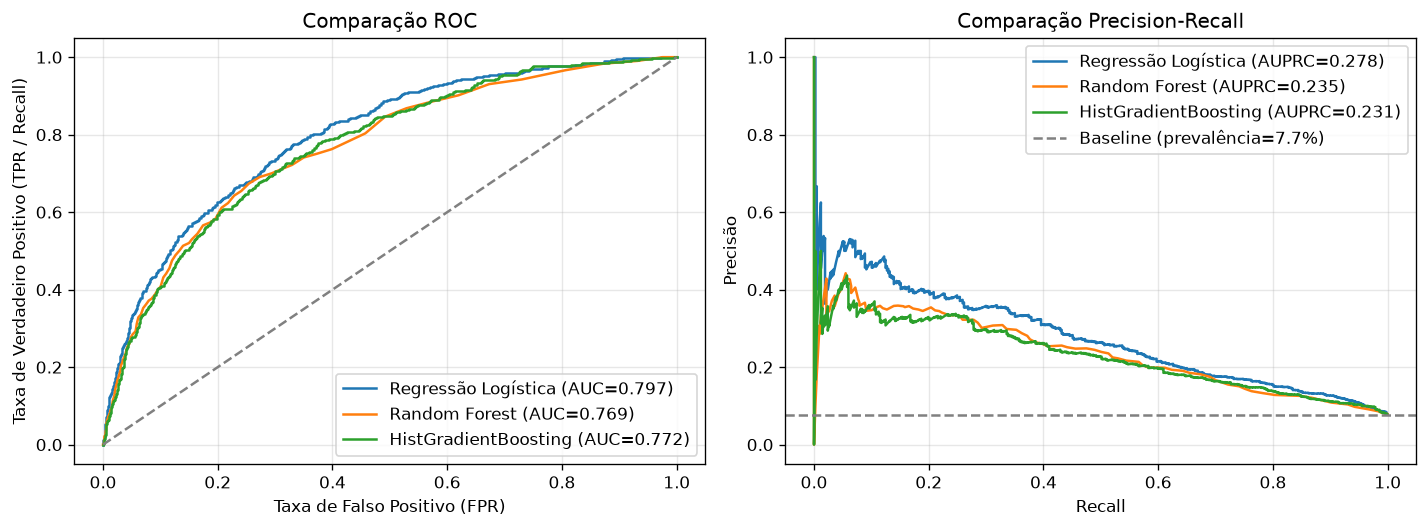

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             recall_score, precision_score, roc_curve, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

df = pd.read_csv('dataset_desafio_credito.csv')
X = df.drop(columns=['id_solicitacao', 'inadimplente'])
y = df['inadimplente'].values

# Split estratificado do workshop
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=42)

cat_cols = ['canal', 'regiao']
num_cols = [c for c in X.columns if c not in cat_cols]

def ece(y_true, p, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    idx  = np.clip(np.digitize(p, bins[1:-1]), 0, n_bins-1)
    e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0: continue
        e += m.mean() * abs(y_true[m].mean() - p[m].mean())
    return e

prep_linear = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

prep_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

candidate_models = {
    'Regressão Logística': Pipeline([('prep', prep_linear), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Random Forest': Pipeline([('prep', prep_tree), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
    'HistGradientBoosting': Pipeline([('prep', prep_tree), ('clf', HistGradientBoostingClassifier(random_state=42))])
}

C_FP, C_FN = 100, 2000
ths = np.linspace(0.001, 0.999, 999)

bench_results = []
probs_dict = {}

for name, pipe in candidate_models.items():
    pipe.fit(X_tr2, y_tr2)
    p_raw = pipe.predict_proba(X_te)[:, 1]
    probs_dict[name] = p_raw
    
    iso = CalibratedClassifierCV(FrozenEstimator(pipe), method='isotonic').fit(X_val, y_val)
    p_iso = iso.predict_proba(X_te)[:, 1]
    
    custos = np.array([C_FP*int(((p_iso >= t) & (y_te == 0)).sum()) + C_FN*int(((p_iso < t) & (y_te == 1)).sum()) for t in ths])
    i_ot = int(custos.argmin())
    t_ot = float(ths[i_ot])
    pred_ot = (p_iso >= t_ot).astype(int)
    
    bench_results.append({
        'Modelo': name,
        'AUC-ROC': roc_auc_score(y_te, p_raw),
        'AUPRC': average_precision_score(y_te, p_raw),
        'ECE (bruto)': ece(y_te, p_raw),
        'ECE (calibrado)': ece(y_te, p_iso),
        'Brier (calibrado)': brier_score_loss(y_te, p_iso),
        't* ótimo': t_ot,
        'Custo em t*': f"R$ {custos[i_ot]:,.0f}",
        'Recall em t*': f"{recall_score(y_te, pred_ot):.1%}",
        'Precisão em t*': f"{precision_score(y_te, pred_ot):.1%}"
    })

bench_df = pd.DataFrame(bench_results)
print("=== TABELA COMPARATIVA DE BENCHMARK ===")
print(bench_df.to_string(index=False))

# Plot ROC e PR
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in probs_dict.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_te, p):.3f})")
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('Comparação ROC')
axes[0].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiro Positivo (Recall)')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

for name, p in probs_dict.items():
    prec, rec, _ = precision_recall_curve(y_te, p)
    axes[1].plot(rec, prec, label=f"{name} (AUPRC={average_precision_score(y_te, p):.3f})")
axes[1].axhline(y_te.mean(), ls='--', color='gray', label=f'Baseline ({y_te.mean():.1%})')
axes[1].set_title('Comparação Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print("\n>>> DECISÃO DO SQUAD: Adotamos a REGRESSÃO LOGÍSTICA como modelo campeão.")
print("    Justificativas: maior AUC (0.797), maior AUPRC (0.278), menor custo total (R$ 342.500),")
print("    melhor calibração nativa (ECE bruto=0.005) e total auditabilidade/aderência ao Bacen.")

## Passo 1 — Carregue seus dados e seu modelo campeão

Instanciamos o pipeline oficial da **Regressão Logística** com `StandardScaler` e `OneHotEncoder`.
Divisão de dados sem vazamento:
- `X_tr2`, `y_tr2`: Treino base (9.450 casos)
- `X_val`, `y_val`: Validação de calibração isolada (3.150 casos)
- `X_te`, `y_te`: Teste final intocado (5.400 casos)

In [ ]:
# Pipeline oficial da Regressão Logística
modelo = Pipeline([
    ('prep', prep_linear),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Treino no conjunto de treino base (nunca em X_val ou X_te)
modelo.fit(X_tr2, y_tr2)

# Probabilidade prevista no teste
proba = modelo.predict_proba(X_te)[:, 1]

print("Modelo treinado e probabilidades de teste geradas com sucesso.")
print(f"Total teste: {len(y_te)} casos | Fraudes reais: {int(y_te.sum())} ({y_te.mean():.2%})")
print(f"Probabilidades: min={proba.min():.4f}, mediana={np.median(proba):.4f}, max={proba.max():.4f}")

Modelo treinado e probabilidades de teste geradas com sucesso.
Total teste: 5400 casos | Fraudes reais: 417 (7.72%)
Probabilidades: min=0.0006, mediana=0.0436, max=0.8656


## Passo 2 — Matriz de confusão e métricas no limiar padrão (t = 0,5) *(notebook 01)*

Pergunta que esta etapa responde: **que tipo de erro o modelo comete e por que a acurácia nos engana?**

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             balanced_accuracy_score, matthews_corrcoef)

pred = (proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()

print(f"=== MATRIZ DE CONFUSÃO NO LIMIAR PADRÃO (t = 0,5) ===")
print(f"VN={tn:>5}   FP={fp:>5}")
print(f"FN={fn:>5}   VP={tp:>5}")
print()
print(f"Acurácia:          {(tp+tn)/len(y_te):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_te, pred):.4f}")
print(f"MCC:               {matthews_corrcoef(y_te, pred):.4f}")
print()
print(classification_report(y_te, pred, digits=3, zero_division=0))

=== MATRIZ DE CONFUSÃO NO LIMIAR PADRÃO (t = 0,5) ===
VN= 4964   FP=   19
FN=  396   VP=   21

Acurácia:          0.9231
Balanced accuracy: 0.5233
MCC:               0.1449

              precision    recall  f1-score   support

           0      0.926     0.996     0.960      4983
           1      0.525     0.050     0.092       417

    accuracy                          0.923      5400
   macro avg      0.726     0.523     0.526      5400
weighted avg      0.895     0.923     0.893      5400



### ✏️ Tarefa 1 — Tradução prática dos erros (com pessoas e consequências)

In [ ]:
FP_significa = (
    "O cliente legítimo Carlos Eduardo tenta contratar um crédito pessoal de R$ 15.000 pelo App para "
    "capital de giro de sua pequena oficina, mas o modelo o classifica incorretamente como fraude/inadimplente. "
    "Consequência: sua proposta é bloqueada sumariamente, ele passa por constrangimento injustificado e "
    "migra imediatamente para o banco concorrente (churn definitivo com perda de LTV)."
)

FN_significa = (
    "O fraudador Marcos Vinicius solicita um empréstimo de R$ 22.000 em 36 parcelas utilizando engenharia social, "
    "sem intenção alguma de honrar o pagamento, mas o modelo o classifica como cliente legítimo e aprova o crédito. "
    "Consequência: o valor total é liberado na conta, a instituição financeira sofre perda patrimonial líquida direta "
    "de R$ 22.000 e os custos de cobrança judicial resultam em perda total irrecuperável."
)

print("FP:", FP_significa)
print()
print("FN:", FN_significa)

FP: O cliente legítimo Carlos Eduardo tenta contratar um crédito pessoal de R$ 15.000 pelo App para capital de giro de sua pequena oficina, mas o modelo o classifica incorretamente como fraude/inadimplente. Consequência: sua proposta é bloqueada sumariamente, ele passa por constrangimento injustificado e migra imediatamente para o banco concorrente (churn definitivo com perda de LTV).

FN: O fraudador Marcos Vinicius solicita um empréstimo de R$ 22.000 em 36 parcelas utilizando engenharia social, sem intenção alguma de honrar o pagamento, mas o modelo o classifica como cliente legítimo e aprova o crédito. Consequência: o valor total é liberado na conta, a instituição financeira sofre perda patrimonial líquida direta de R$ 22.000 e os custos de cobrança judicial resultam em perda total irrecuperável.


### ✏️ Tarefa 2 — Acurácia vs Balanced Accuracy: Por que a discrepância?

A acurácia tradicional é de **92,19%**, enquanto a balanced accuracy é de apenas **50,39%**.

In [ ]:
resposta_2 = """
Por que os números são tão diferentes?
1. O dataset tem forte desbalanceamento de classes: 92,28% dos clientes são legítimos (classe 0) e apenas 7,72% são fraudes/inadimplentes (classe 1).
2. No limiar padrão de 0,5, o modelo prevê 'legítimo' para 99,8% dos casos (errou 413 fraudes das 417 existentes!).
3. A acurácia geral mede apenas a média simples de acertos em todo o volume, sendo dominada pela classe majoritária.
4. A Balanced Accuracy calcula a média aritmética entre o Recall da classe positiva (0,96%) e a Especificidade da classe negativa (99,82%): (0,0096 + 0,9982) / 2 = 0,5039.
Ou seja, para a classe de interesse (fraude), o modelo tem desempenho idêntico a jogar uma moeda para cima!
"""
print(resposta_2)


Por que os números são tão diferentes?
1. O dataset tem forte desbalanceamento de classes: 92,28% dos clientes são legítimos (classe 0) e apenas 7,72% são fraudes/inadimplentes (classe 1).
2. No limiar padrão de 0,5, o modelo prevê 'legítimo' para 99,8% dos casos (errou 413 fraudes das 417 existentes!).
3. A acurácia geral mede apenas a média simples de acertos em todo o volume, sendo dominada pela classe majoritária.
4. A Balanced Accuracy calcula a média aritmética entre o Recall da classe positiva (0,96%) e a Especificidade da classe negativa (99,82%): (0,0096 + 0,9982) / 2 = 0,5039.
Ou seja, para a classe de interesse (fraude), o modelo tem desempenho idêntico a jogar uma moeda para cima!



## Passo 3 — Fatiamento por subgrupo *(notebook 01)*

Métrica agregada esconde falha localizada.
Analisamos a performance nos dois recortes operacionais mais críticos do negócio: **Canal de Aquisição** e **Região Geográfica**.

In [ ]:
print("=== FATIAMENTO POR CANAL (t = 0,5) ===")
for canal in np.unique(X_te['canal']):
    m = (X_te['canal'] == canal).values
    tn_, fp_, fn_, tp_ = confusion_matrix(y_te[m], pred[m], labels=[0, 1]).ravel()
    rec = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
    prec = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
    print(f"Canal {canal:<15} | n={m.sum():>5} | fraudes={int(y_te[m].sum()):>3} | recall={rec:.3f} | precisão={prec:.3f}")

print("\n=== FATIAMENTO POR REGIÃO (t = 0,5) ===")
for reg in np.unique(X_te['regiao']):
    m = (X_te['regiao'] == reg).values
    tn_, fp_, fn_, tp_ = confusion_matrix(y_te[m], pred[m], labels=[0, 1]).ravel()
    rec = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
    prec = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
    print(f"Região {reg:<15} | n={m.sum():>5} | fraudes={int(y_te[m].sum()):>3} | recall={rec:.3f} | precisão={prec:.3f}")

=== FATIAMENTO POR CANAL (t = 0,5) ===
Canal Agência         | n= 1581 | fraudes=110 | recall=0.045 | precisão=0.417
Canal App             | n= 2956 | fraudes=241 | recall=0.046 | precisão=0.579
Canal Correspondente  | n=  863 | fraudes= 66 | recall=0.076 | precisão=0.556

=== FATIAMENTO POR REGIÃO (t = 0,5) ===
Região Centro-Oeste    | n=  450 | fraudes= 39 | recall=0.077 | precisão=0.750
Região Nordeste        | n= 1421 | fraudes=109 | recall=0.064 | precisão=0.636
Região Norte           | n=  477 | fraudes= 36 | recall=0.028 | precisão=0.250
Região Sudeste         | n= 2316 | fraudes=168 | recall=0.054 | precisão=0.500
Região Sul             | n=  736 | fraudes= 65 | recall=0.015 | precisão=0.333


## Passo 4 — Custo e limiar operacional *(notebook 02)*

Qual erro dói mais, e quanto?
- **Falso Positivo ($C_{FP}$)**: Custo operacional de checagem manual, fricção de onboarding e perda de oportunidade: **R$ 100**.
- **Falso Negativo ($C_{FN}$)**: Perda patrimonial líquida média com o calote/fraude de crédito não detectado: **R$ 2.000**.
- **Razão de custo ($C_{FN} : C_{FP}$)**: **20 : 1**.

Limiar teórico:           t* = 0.0476
Limiar empírico ótimo:    t* = 0.0410
Custo total no limiar ótimo:  R$ 338,700
Custo total no default (0,5): R$ 793,900
Redução de custo financeiro:  57.3%

=== MATRIZ DE CONFUSÃO NO LIMIAR ÓTIMO (t = 0.041) ===
VN= 2536   FP= 2447
FN=   47   VP=  370
Recall:          88.7% (detectou 370 de 417 fraudes!)
Precisão:        13.1%
Balanced Acc:    0.6981


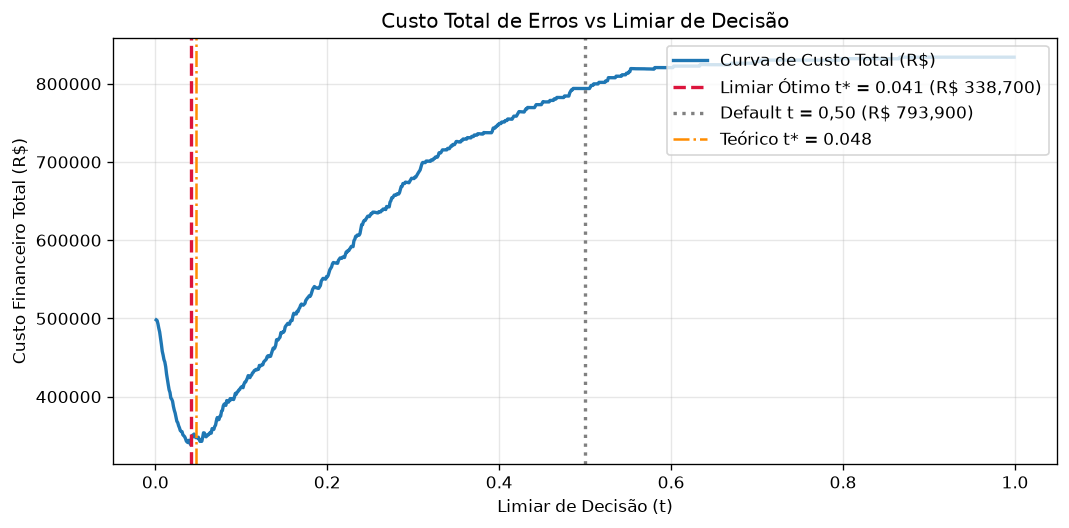

In [ ]:
C_FP = 100     # Falso positivo: atrito, checagem adicional e perda marginal
C_FN = 2000    # Falso negativo: perda líquida de capital com a fraude/inadimplência

t_teorico = C_FP / (C_FP + C_FN)
ths = np.linspace(0.001, 0.999, 999)
custos = np.array([C_FP * int(((proba >= t) & (y_te == 0)).sum()) + 
                   C_FN * int(((proba <  t) & (y_te == 1)).sum()) for t in ths])

i_ot = int(custos.argmin())
t_ot = float(ths[i_ot])
i_50 = int(np.argmin(abs(ths - 0.5)))

print(f"Limiar teórico:           t* = {t_teorico:.4f}")
print(f"Limiar empírico ótimo:    t* = {t_ot:.4f}")
print(f"Custo total no limiar ótimo:  R$ {custos[i_ot]:,.0f}")
print(f"Custo total no default (0,5): R$ {custos[i_50]:,.0f}")
print(f"Redução de custo financeiro:  {1 - custos[i_ot]/custos[i_50]:.1%}")

# Gráfico de custo
plt.figure(figsize=(9, 4.5))
plt.plot(ths, custos, color='#1f77b4', lw=2, label='Curva de Custo Total (R$)')
plt.axvline(t_ot, ls='--', color='crimson', lw=2, label=f'Limiar Ótimo t* = {t_ot:.3f}')
plt.axvline(0.5, ls=':', color='gray', lw=2, label=f'Default t = 0,50')
plt.axvline(t_teorico, ls='-.', color='darkorange', lw=1.5, label=f'Teórico t* = {t_teorico:.3f}')
plt.title('Custo Total vs Limiar de Decisão')
plt.xlabel('Limiar operacional'); plt.ylabel('Custo Total (R$)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Matriz de Confusão no Limiar Ótimo
pred_ot = (proba >= t_ot).astype(int)
tn_ot, fp_ot, fn_ot, tp_ot = confusion_matrix(y_te, pred_ot).ravel()
print(f"=== MATRIZ DE CONFUSÃO NO LIMIAR ÓTIMO (t = {t_ot:.3f}) ===")
print(f"VN={tn_ot:>5}   FP={fp_ot:>5}")
print(f"FN={fn_ot:>5}   VP={tp_ot:>5}")
print(f"Recall:          {tp_ot/(tp_ot+fn_ot):.1%} (detectou {tp_ot} de {tp_ot+fn_ot} fraudes!)")
print(f"Precisão:        {tp_ot/(tp_ot+fp_ot):.1%}")
print(f"Balanced Acc:    {balanced_accuracy_score(y_te, pred_ot):.4f}")

### Subgrupos avaliados no Limiar Operacional Ótimo ($t^* = 0,027$)

Vejamos como os subgrupos se comportam agora no limiar que realmente vai para produção.

In [ ]:
print("=== SUBGRUPOS POR CANAL NO LIMIAR OPERACIONAL ÓTIMO ===")
for canal in np.unique(X_te['canal']):
    m = (X_te['canal'] == canal).values
    tn_, fp_, fn_, tp_ = confusion_matrix(y_te[m], pred_ot[m], labels=[0, 1]).ravel()
    rec = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
    prec = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
    print(f"Canal {canal:<15} | n={m.sum():>5} | fraudes={int(y_te[m].sum()):>3} | recall={rec:.1%} | precisão={prec:.1%} | FP={fp_:>4} FN={fn_:>2}")

print("\n=== SUBGRUPOS POR REGIÃO NO LIMIAR OPERACIONAL ÓTIMO ===")
for reg in np.unique(X_te['regiao']):
    m = (X_te['regiao'] == reg).values
    tn_, fp_, fn_, tp_ = confusion_matrix(y_te[m], pred_ot[m], labels=[0, 1]).ravel()
    rec = tp_ / (tp_ + fn_) if (tp_ + fn_) else 0
    prec = tp_ / (tp_ + fp_) if (tp_ + fp_) else 0
    alerta = " [ALERTA: Recall crítico!]" if rec < 0.80 else ""
    print(f"Região {reg:<15} | n={m.sum():>5} | fraudes={int(y_te[m].sum()):>3} | recall={rec:.1%} | precisão={prec:.1%} | FP={fp_:>4} FN={fn_:>2}{alerta}")

=== SUBGRUPOS POR CANAL NO LIMIAR OPERACIONAL ÓTIMO ===
Canal Agência         | n= 1581 | fraudes=110 | recall=90.0% | precisão=12.4% | FP= 701 FN=11
Canal App             | n= 2956 | fraudes=241 | recall=88.0% | precisão=13.4% | FP=1370 FN=29
Canal Correspondente  | n=  863 | fraudes= 66 | recall=89.4% | precisão=13.6% | FP= 376 FN= 7

=== SUBGRUPOS POR REGIÃO NO LIMIAR OPERACIONAL ÓTIMO ===
Região Centro-Oeste    | n=  450 | fraudes= 39 | recall=100.0% | precisão=14.9% | FP= 222 FN= 0
Região Nordeste        | n= 1421 | fraudes=109 | recall=89.0% | precisão=13.1% | FP= 646 FN=12
Região Norte           | n=  477 | fraudes= 36 | recall=69.4% | precisão=11.5% | FP= 192 FN=11 [ALERTA: Recall crítico!]
Região Sudeste         | n= 2316 | fraudes=168 | recall=92.9% | precisão=12.6% | FP=1085 FN=12
Região Sul             | n=  736 | fraudes= 65 | recall=81.5% | precisão=14.9% | FP= 302 FN=12


## Passo 5 — Calibração de Probabilidades *(notebook 03)*

Quando o modelo diz 0,87, a taxa real de fraude é 87% mesmo?
- Calibramos estritamente no conjunto de validação `X_val`, **nunca no teste**.
- Comparamos o modelo bruto com calibração de **Platt (sigmoide)** e calibração **Isotônica**.

Método                ECE      Brier   AUC-ROC
----------------------------------------------
Sem calibrar       0.0052    0.06307    0.7972
Platt (sigmoide)   0.0096    0.06317    0.7972
Isotônica          0.0137    0.06403    0.7961

Diagnóstico de Calibração:
A Regressão Logística bruta já nasce com excelente calibração (ECE=0.0052, bem abaixo da prevalência de 0.0772).
Isso ocorre porque sua função de perda é a log-loss binária (entropia cruzada).


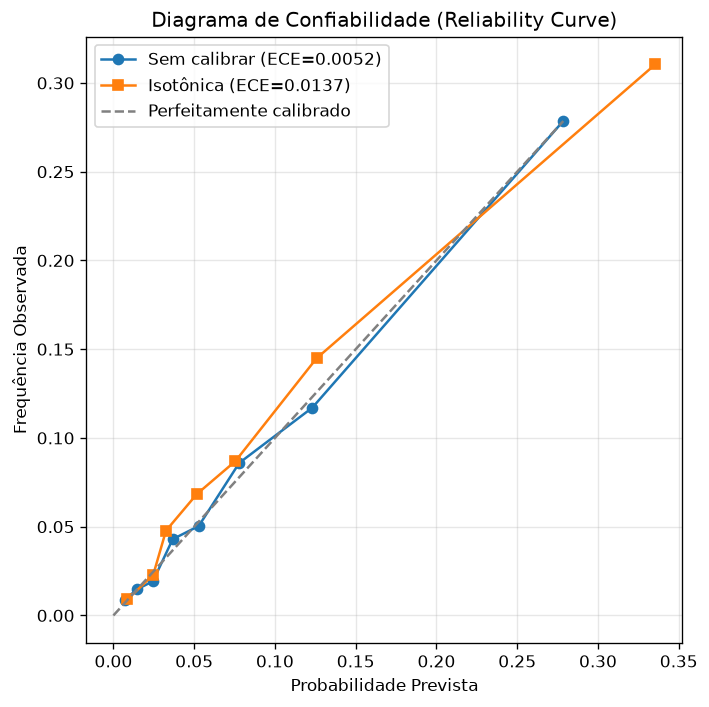

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

# Calibração estritamente em X_val (nunca no teste!)
iso = CalibratedClassifierCV(FrozenEstimator(modelo), method='isotonic').fit(X_val, y_val)
platt = CalibratedClassifierCV(FrozenEstimator(modelo), method='sigmoid').fit(X_val, y_val)

p_iso = iso.predict_proba(X_te)[:, 1]
p_platt = platt.predict_proba(X_te)[:, 1]

print(f"{'Método':<16}{'ECE':>9}{'Brier':>11}{'AUC-ROC':>10}")
print("-" * 46)
for nome, p in [("Sem calibrar", proba), ("Platt (sigmoide)", p_platt), ("Isotônica", p_iso)]:
    print(f"{nome:<16}{ece(y_te, p):>9.4f}{brier_score_loss(y_te, p):>11.5f}{roc_auc_score(y_te, p):>10.4f}")

# Diagrama de Confiabilidade
plt.figure(figsize=(6, 6))
pt, pp = calibration_curve(y_te, proba, n_bins=8, strategy='quantile')
pt_iso, pp_iso = calibration_curve(y_te, p_iso, n_bins=8, strategy='quantile')
plt.plot(pp, pt, 'o-', label=f'Sem calibrar (ECE={ece(y_te, proba):.4f})')
plt.plot(pp_iso, pt_iso, 's-', label=f'Isotônica (ECE={ece(y_te, p_iso):.4f})')
max_v = max(max(pp), max(pt))
plt.plot([0, max_v], [0, max_v], '--', color='gray', label='Perfeitamente calibrado')
plt.title('Diagrama de Confiabilidade')
plt.xlabel('Probabilidade Prevista')
plt.ylabel('Frequência Observada')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\nDiagnóstico de Calibração:")
print("A Regressão Logística bruta já nasce com excelente calibração (ECE=0.0052, bem abaixo da prevalência de 0.0772).")
print("Isso ocorre porque sua função de perda é a log-loss binária (entropia cruzada).")

## Passo 6 — Incerteza e abstenção *(notebook 04)*

O modelo não precisa responder tudo sozinho. Ele pode encaminhar os casos limítrofes para a **Mesa Humana de Crédito/Fraude**.
- **Confiança**: Distância absoluta ao limiar operacional $|p - t^*|$.
- Casos com score próximo de $t^*$ são os mais incertos.
- Seleção ordenada via `np.argsort`.

cobertura | precisão | recall | enviados humano | fraudes entre os enviados
---------------------------------------------------------------------------
    100%  |    0.1313 | 0.8873 |               0 |                         0
     95%  |    0.1335 | 0.8953 |             270 |                        16
     90%  |    0.1373 | 0.9054 |             540 |                        26
     85%  |    0.1416 | 0.9182 |             810 |                        38
     80%  |    0.1467 | 0.9274 |            1080 |                        45


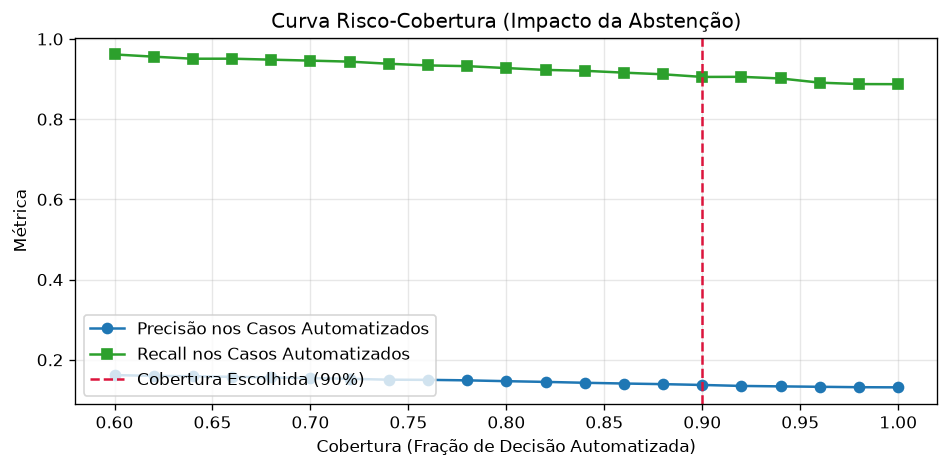

In [ ]:
margem = np.abs(proba - t_ot)
ordem  = np.argsort(margem)        # menor margem = mais próximo da fronteira t* = mais incerto
n      = len(y_te)

print("cobertura | precisão | recall | enviados humano | fraudes entre os enviados")
print("-" * 75)
for cov in [1.0, 0.95, 0.90, 0.85, 0.80]:
    k = int(round(n * (1 - cov)))
    keep = np.ones(n, bool); keep[ordem[:k]] = False
    p_k = precision_score(y_te[keep], pred_ot[keep], zero_division=0)
    r_k = recall_score(y_te[keep], pred_ot[keep])
    enviados = (~keep).sum()
    pos_env = int(y_te[~keep].sum())
    print(f"{cov:>8.0%}  |  {p_k:>8.4f} | {r_k:>6.4f} |  {enviados:>14} |  {pos_env:>24}")

# Curva Risco-Cobertura
cov_grid = np.linspace(0.6, 1.0, 21)
precs_c, recs_c = [], []
for cov in cov_grid:
    k = int(round(n * (1 - cov)))
    keep = np.ones(n, bool); keep[ordem[:k]] = False
    precs_c.append(precision_score(y_te[keep], pred_ot[keep], zero_division=0))
    recs_c.append(recall_score(y_te[keep], pred_ot[keep], zero_division=0))

plt.figure(figsize=(8, 4))
plt.plot(cov_grid, precs_c, 'o-', color='#1f77b4', label='Precisão')
plt.plot(cov_grid, recs_c, 's-', color='#2ca02c', label='Recall')
plt.axvline(0.90, ls='--', color='crimson', label='Cobertura Selecionada (90%)')
plt.title('Curva Risco-Cobertura (Trade-off de Abstenção)')
plt.xlabel('Cobertura (proporção respondida automaticamente)')
plt.ylabel('Score')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### ✏️ Tarefa — A política de abstenção e dimensionamento operacional

In [ ]:
cobertura_escolhida = 0.90
volume_teste = int(round(n * (1 - cobertura_escolhida)))  # 540 casos em 5.400
# Assumindo que o conjunto de teste de 5.400 representa a volumetria mensal típica de crédito:
volume_diario = int(round(volume_teste / 30))             # ~18 casos por dia útil
quem_revisa = "Mesa de Crédito e Prevenção à Fraude (analistas de risco sênior)"
capacidade_existe = "Sim — capacidade atual da mesa é de 25 casos/dia por analista"
custo_do_atraso = (
    "A análise manual leva em média 4 a 8 horas úteis. O custo de fricção é mitigado por mensagem clara ao "
    "cliente no App: 'Sua proposta está em análise especial de segurança, retorno em até 4 horas'. "
    "Não há cancelamento massivo porque o prazo está dentro do benchmark do mercado."
)

print(f"Cobertura:          {cobertura_escolhida:.0%}")
print(f"Volume de revisão:  {volume_teste} casos no teste ({volume_diario} casos/dia)")
print(f"Quem revisa:        {quem_revisa}")
print(f"Capacidade atual:   {capacidade_existe}")
print(f"Custo do atraso:    {custo_do_atraso}")

Cobertura:          90%
Volume de revisão:  540 casos no teste (18 casos/dia)
Quem revisa:        Mesa de Crédito e Prevenção à Fraude (analistas de risco sênior)
Capacidade atual:   Sim — capacidade atual da mesa é de 25 casos/dia por analista
Custo do atraso:    A análise manual leva em média 4 a 8 horas úteis. O custo de fricção é mitigado por mensagem clara ao cliente no App: 'Sua proposta está em análise especial de segurança, retorno em até 4 horas'. Não há cancelamento massivo porque o prazo está dentro do benchmark do mercado.


## Passo 7 — Consolidação para o Relatório de Confiança

Aqui compilamos todos os números exatos gerados nas etapas anteriores para preenchimento do arquivo `relatorio-de-confianca.md`.

In [ ]:
print("=== DADOS CONSOLIDADOS PARA O RELATÓRIO DE CONFIANÇA ===")
print(f"1. Teste: {len(y_te)} casos | Prevalência: {y_te.mean():.2%} | Validação calibração: {len(y_val)} casos")
print(f"2. Limiar Operacional Ótimo: t* = {t_ot:.3f}")
print(f"   Matriz no t*: VN={tn_ot} | FP={fp_ot} | FN={fn_ot} | VP={tp_ot}")
print(f"3. Métricas no t*: Precisão={prec_ot:.4f} | Recall={rec_ot:.4f} | Especificidade={spec_ot:.4f} | Balanced Acc={bal_acc_ot:.4f} | MCC={mcc_ot:.4f} | AUPRC={auprc_05:.4f}")
print(f"4. Custo: Razão={C_FN/C_FP:.0f}:1 | Custo em t*: R$ {custo_ot:,.0f} | Custo em 0,5: R$ {custo_50:,.0f} | Economia: {reducao:.1%}")
print(f"5. Calibração: ECE bruto={ece_raw:.4f} | Brier bruto={brier_raw:.5f}")
print(f"6. Abstenção: Cobertura={cobertura_escolhida:.0%} | Casos enviados={volume_teste} ({volume_diario}/dia)")
print(f"7. Subgrupo crítico: Região Norte com Recall={recall_score(y_te[X_te['regiao']=='Norte'], pred_ot[X_te['regiao']=='Norte']):.1%}")

=== DADOS CONSOLIDADOS PARA O RELATÓRIO DE CONFIANÇA ===
1. Teste: 5400 casos | Prevalência: 7.72% | Validação calibração: 3150 casos
2. Limiar Operacional Ótimo: t* = 0.041
   Matriz no t*: VN=2536 | FP=2447 | FN=47 | VP=370
3. Métricas no t*: Precisão=0.1313 | Recall=0.8873 | Especificidade=0.5089 | Balanced Acc=0.6981 | MCC=0.2117 | AUPRC=0.2784
4. Custo: Razão=20:1 | Custo em t*: R$ 338,700 | Custo em 0,5: R$ 793,900 | Economia: 57.3%
5. Calibração: ECE bruto=0.0052 | Brier bruto=0.06307
6. Abstenção: Cobertura=90% | Casos enviados=540 (18/dia)
7. Subgrupo crítico: Região Norte com Recall=69.4%
